 Titanic Survival Prediction Project
 This project uses machine learning to predict whether a passenger survived
 the Titanic disaster based on features like age, gender, class, etc.

In [86]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

 Loading dataset
 Dataset used is Titanic dataset

In [87]:
df = pd.read_csv("titanic.csv")
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


DATA CLEANING:
Removing unnecessary and handling missing values

In [88]:

df.drop(['alive'], axis=1, inplace=True)
df['age'].fillna(df['age'].mean(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

/tmp/ipykernel_14478/3032932988.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(), inplace=True)
/tmp/ipykernel_14478/3032932988.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

Feature Engineering
Creating new features:
family_size = number of family members onboard
is_alone = whether passenger is traveling alone

In [89]:
df['family_size'] = df['sibsp'] + df['parch']
df['is_alone'] = (df['family_size'] == 0).astype(int)

Converting categorical variables into numerical form using one-hot encoding

In [90]:
df = pd.get_dummies(df, drop_first=True)
df.fillna(0, inplace=True)

Feature and target spliting

In [91]:
x = df.drop('survived', axis=1)
y = df['survived']

Train-Test Split

In [92]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

MODEL TRAINING

In [93]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=300,
    max_depth=7,
    random_state=42)
}

for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    print(f"{name} Accuracy:", accuracy_score(y_test, pred)*100)
model.fit(X_train, y_train)

Logistic Regression Accuracy: 82.12290502793296
Random Forest Accuracy: 83.24022346368714


RandomForestClassifier(max_depth=7, n_estimators=300, random_state=42)

EVALUATION

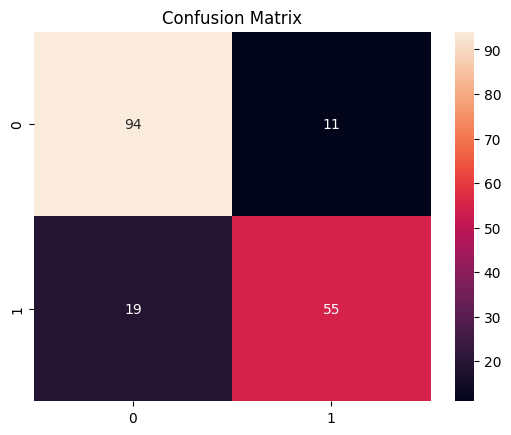

In [94]:
from sklearn.metrics import confusion_matrix
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

ROC Curve
Evaluates model performance across different classification thresholds

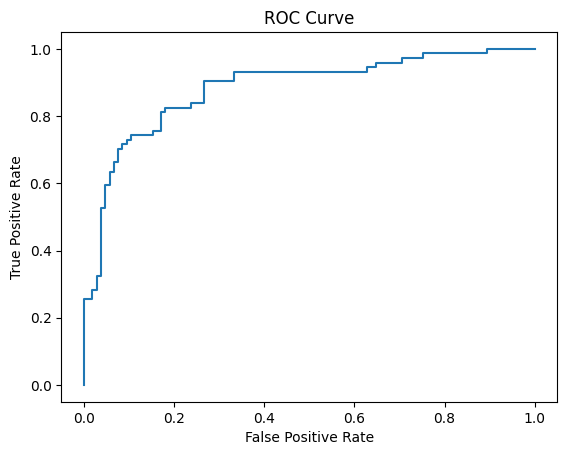

In [95]:
from sklearn.metrics import roc_curve, auc
y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

Classification Report
Includes precision, recall, and F1-score for better evaluation

In [96]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86       105
           1       0.83      0.74      0.79        74

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



Visualizing distribution of survival in dataset

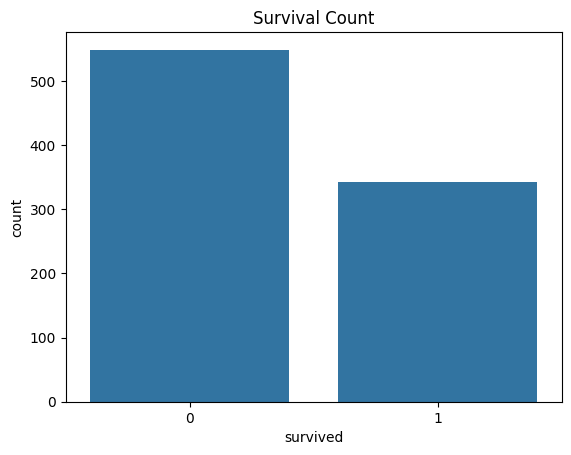

In [97]:
sns.countplot(x='survived', data=df)
plt.title("Survival Count")
plt.show()

Feature Importance
Shows which features contribute most to prediction
Important for model interpretability

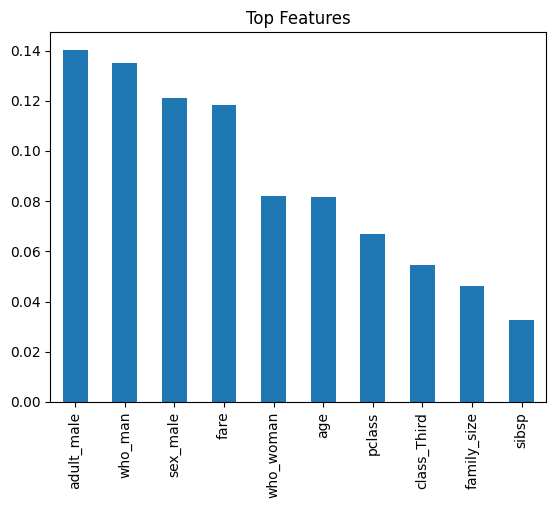

In [99]:

feature_importance = pd.Series(model.feature_importances_, index=x.columns)
feature_importance.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Features")
plt.show()

Conclusion:
Model Performance
The model achieved: 82-83% accuracy. It performs well on both classes with some misclassification.
Important factors influencing survival include gender, class, and family size.
Further improvements can be made using hyperparameter tuning and advanced models.